In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp



## Funções

In [57]:


def degrau(t):
    """Unit step function (alternative)."""
    return np.heaviside(t, 1)


def exponential(t):
    """Exponential function."""
    return np.exp(-t) 

def sinal_continuo(t):
    """Ramp function."""
    return np.where(t >= 0, t, 0)

def unit_impulse(t):
    """Unit impulse function."""
    return np.where(t == 0, 1, 0)

def square_wave(t, T):
    """Square wave function."""
    return np.where((t % T) < (T / 2), 1, -1)

def wave_square(t):
    return np.where(t%2 <1, 1, -1)

def f(x):
    """Function to be integrated."""
    return np.exp(-x**2)

def g(t):
    return np.exp(t)

def triangular_wave(t, T):
    """Triangular wave function."""
    return 1 - 2 * np.abs((t % T) / T - 0.5)



## Graficos

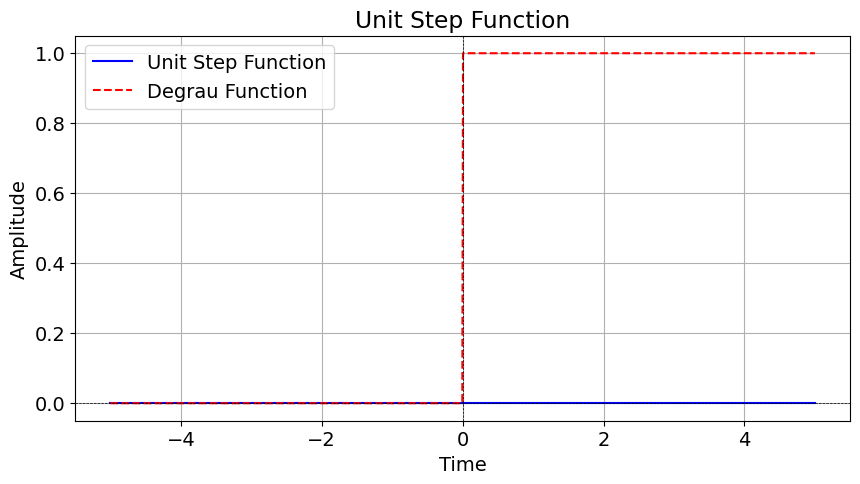

In [58]:
tempo = np.linspace(-5, 5, 1000)

y = unit_impulse(tempo)
y2 = degrau(tempo)

# Plotting the unit step function
plt.figure(figsize=(10, 5))
plt.plot(tempo, y, label='Unit Step Function', color='blue')
plt.plot(tempo, y2, label='Degrau Function', linestyle='--', color='red')
plt.title('Unit Step Function')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid()
plt.legend()
plt.show()

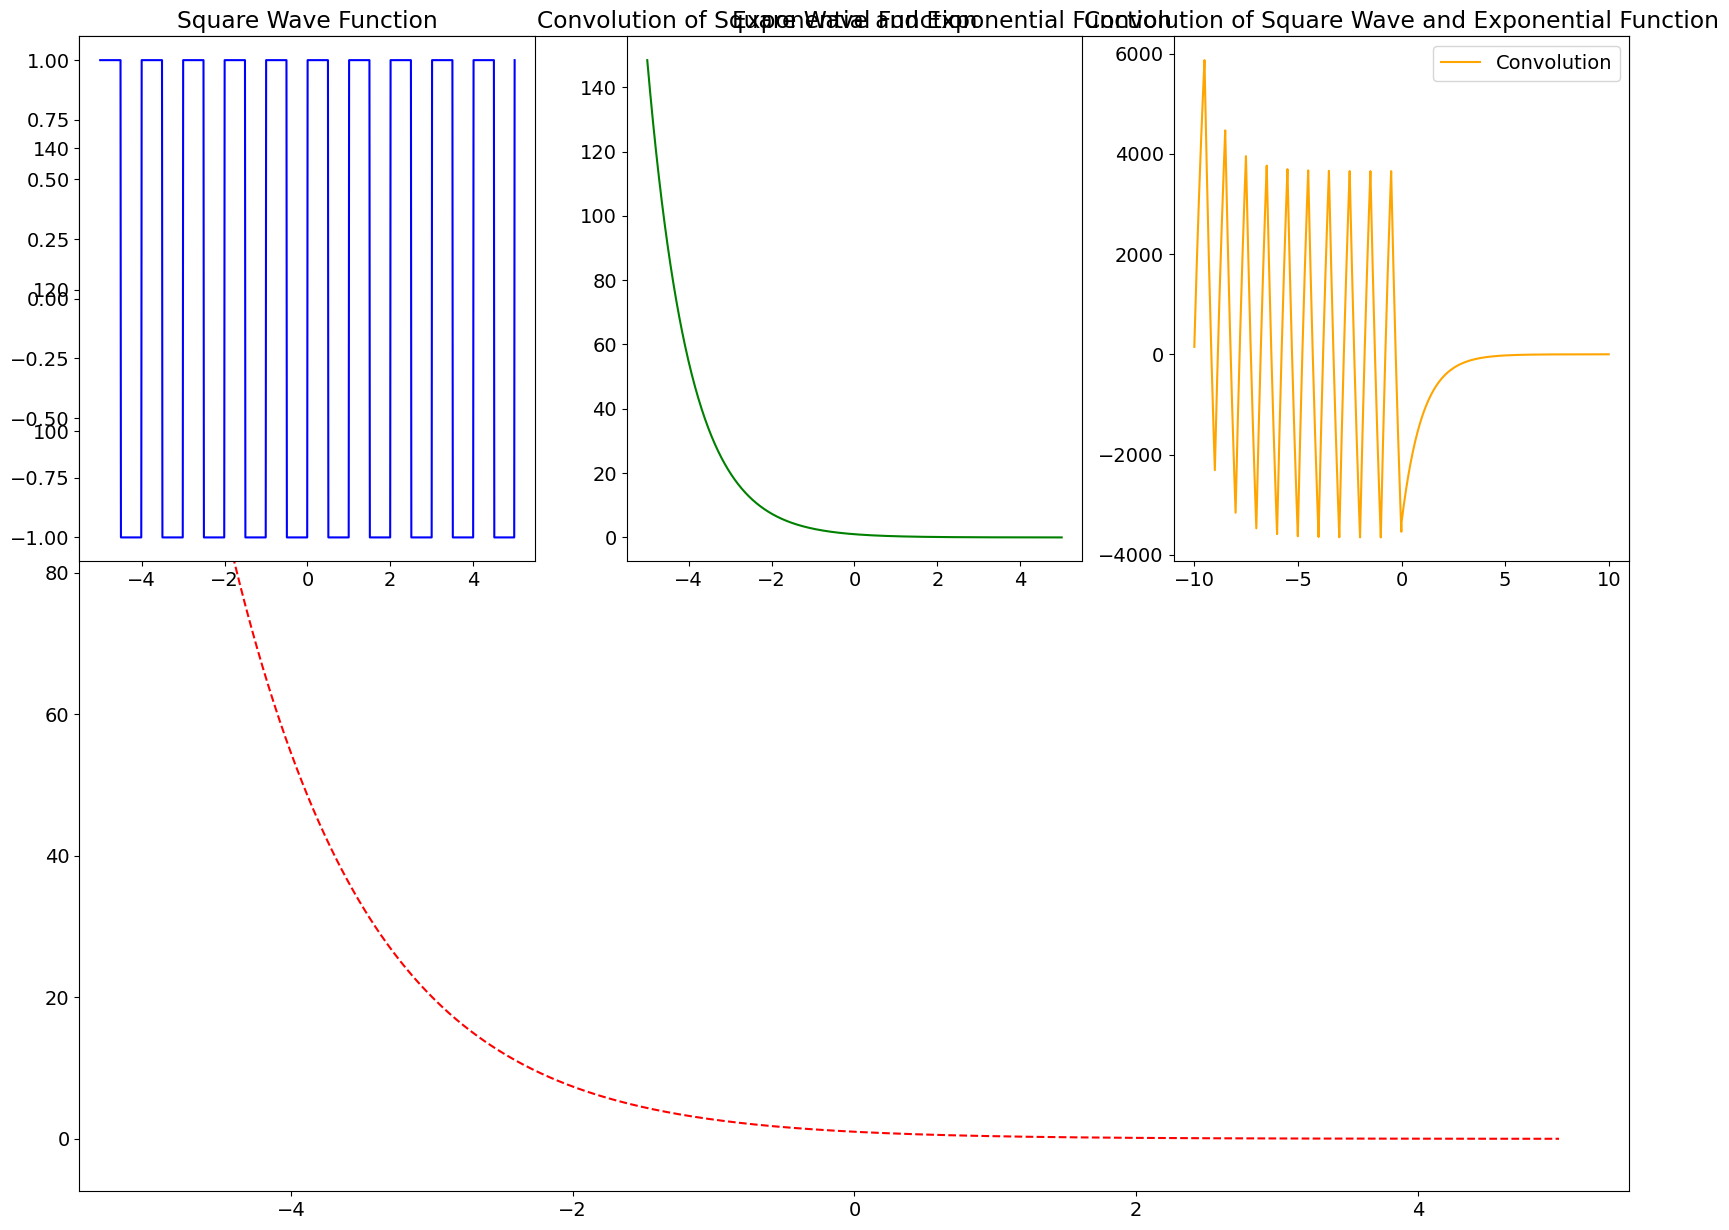

In [59]:
t = np.linspace(-5, 5, 1000)
y1 = square_wave(t,1)
y2 = exponential(t)

y = np.convolve(y1, y2, mode='full')  # Convolution
t_conv = np.linspace(-10, 10, len(y))


plt.figure(figsize=(20, 15))
plt.plot(tempo, y2, label='Degrau Function', linestyle='--', color='red')
plt.title('Convolution of Square Wave and Exponential Function')
plt.subplot(2,3,1)
plt.plot(t,y1, label='Square Wave', color='blue')
plt.title('Square Wave Function')

plt.subplot(2,3,2)
plt.plot(t,y2, label='Exponential Function', color='green')
plt.title('Exponential Function')
plt.subplot(2,3,3)
plt.plot(t_conv, y, label='Convolution', color='orange')
plt.title('Convolution of Square Wave and Exponential Function')

plt.legend()
# Plotting the square wave function

Tabelas e Analise de dados

## Espectro e serie de fourier 

In [60]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 14})
from scipy import signal

fs = 1000  # Sampling frequency
t  = np.arange(0, 3, 1/fs)  # Time vector
f = 1 
w1 = 2*np.pi*f

x_t = signal.square(2*np.pi * f * t) # Square wave

x_t


array([ 1.,  1.,  1., ..., -1., -1., -1.])

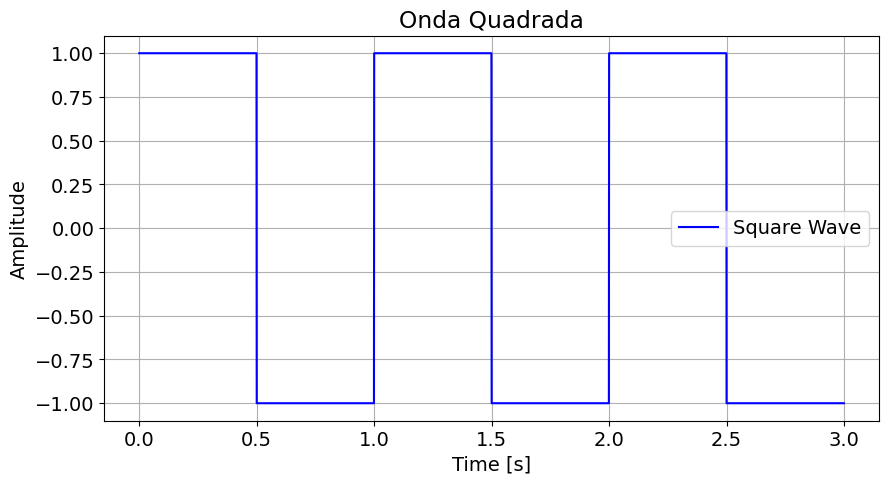

In [61]:
# grafico
plt.figure(figsize=(10, 5))
plt.title("Onda Quadrada")
plt.plot(t, x_t, label='Square Wave', color='blue')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

Coeficentes

C:\Users\Pedro Victor R V\AppData\Local\Temp\ipykernel_5952\516861703.py:5: RuntimeWarning: divide by zero encountered in divide
  ck = (-1j/(np.pi*k)) * (1-np.cos(k*np.pi))
C:\Users\Pedro Victor R V\AppData\Local\Temp\ipykernel_5952\516861703.py:5: RuntimeWarning: invalid value encountered in divide
  ck = (-1j/(np.pi*k)) * (1-np.cos(k*np.pi))
C:\Users\Pedro Victor R V\AppData\Local\Temp\ipykernel_5952\516861703.py:5: RuntimeWarning: invalid value encountered in multiply
  ck = (-1j/(np.pi*k)) * (1-np.cos(k*np.pi))


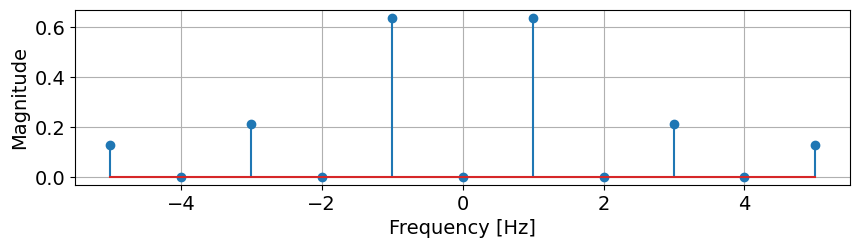

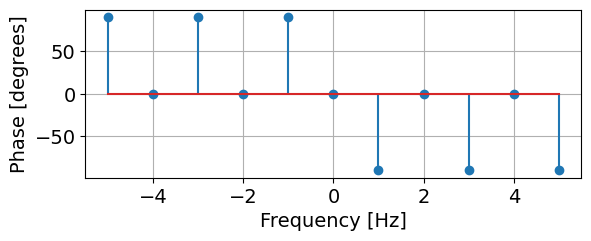

In [62]:
max_k =5
k = np.arange(-max_k, max_k+1)
freq_vetor = k * f

ck = (-1j/(np.pi*k)) * (1-np.cos(k*np.pi))

#ck = np.fft.fft(x_t) / len(x_t)
ck[(k%2) == 0] = 0

# Plotting the Espectro 
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.stem(freq_vetor, np.abs(ck))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

plt.subplot(2, 1, 2)
plt.stem(freq_vetor, np.rad2deg(np.angle(ck)))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase [degrees]')
plt.grid()
plt.show()



Reconstruindo meu sinal

In [63]:
xt__ntx = np.zeros((len(k), len(t)),dtype=complex)

for jk in np.arange(len(k)):
    xt__ntx[jk,:] = ck[jk] * np.exp(1j *k[jk] * w1 * t)


xt_reconstruido = np.sum(xt__ntx, axis=0)
xt_reconstruido

array([ 0.        +2.77555756e-17j,  0.02399816+0.00000000e+00j,
        0.04798526-2.77555756e-17j, ..., -0.07195028+0.00000000e+00j,
       -0.04798526-2.77555756e-17j, -0.02399816-2.77555756e-17j])

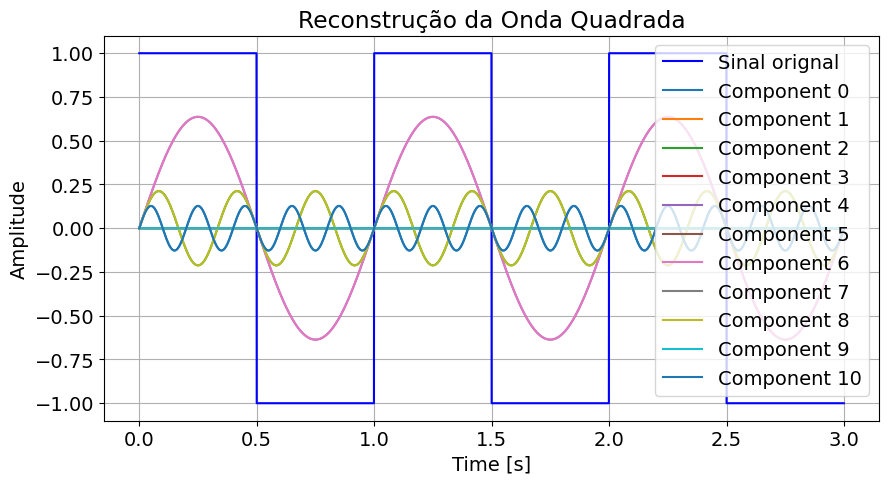

In [64]:

plt.figure(figsize=(10, 5))
plt.title("Reconstrução da Onda Quadrada")
plt.plot(t, x_t, label='Sinal orignal', color='blue')
for jk in np.arange(len(k)):
    plt.plot(t, xt__ntx[jk,:].real, label=f'Component {jk}')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()


Sinal original e o reconstruido

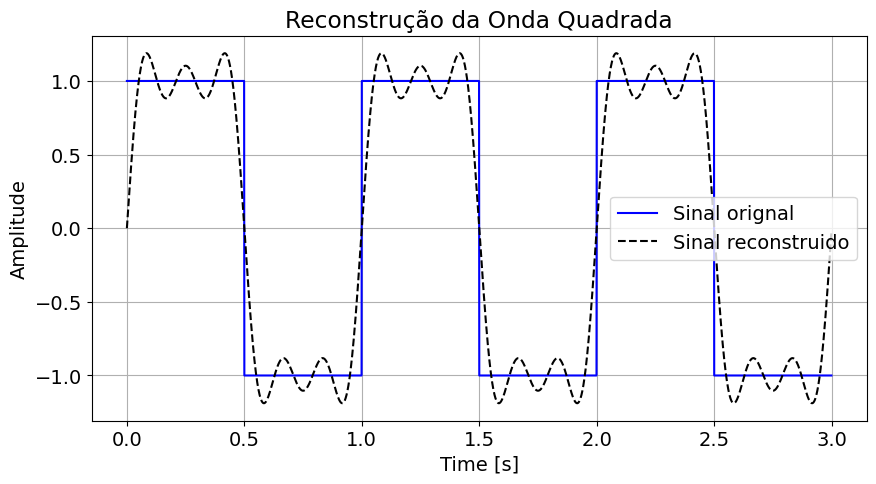

In [65]:

plt.figure(figsize=(10, 5))
plt.title("Reconstrução da Onda Quadrada")
plt.plot(t, x_t, label='Sinal orignal', color='blue')
plt.plot(t, xt_reconstruido.real, label='Sinal reconstruido', linestyle='--', color='black')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()


<>:85: SyntaxWarning: invalid escape sequence '\p'
<>:85: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Pedro Victor R V\AppData\Local\Temp\ipykernel_5952\3468290773.py:85: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Fase $\phi_n$ (graus)')


Sinal: Trem de Pulsos (A=1.0, T0=1.0, tau=0.5)
n | an      | bn      | Magnitude | Fase (rad) | Fase (deg) | Freq (Hz)
----------------------------------------------------------------------
0  | 0.5000  | 0.0000  | 0.5000    | 0.0000     | 0.00      | 0.00     
1  | 0.0000  | 0.6366  | 0.6366    | -1.5708    | -90.00    | 1.00     
2  | -0.0000 | 0.0000  | 0.0000    | -3.1416    | -180.00   | 2.00     
3  | 0.0000  | 0.2122  | 0.2122    | -1.5708    | -90.00    | 3.00     
4  | -0.0000 | 0.0000  | 0.0000    | -3.1416    | -180.00   | 4.00     
5  | 0.0000  | 0.1273  | 0.1273    | -1.5708    | -90.00    | 5.00     
6  | -0.0000 | 0.0000  | 0.0000    | -3.1416    | -180.00   | 6.00     
7  | 0.0000  | 0.0909  | 0.0909    | -1.5708    | -90.00    | 7.00     
8  | -0.0000 | 0.0000  | 0.0000    | -3.1416    | -180.00   | 8.00     
9  | 0.0000  | 0.0707  | 0.0707    | -1.5708    | -90.00    | 9.00     
10 | -0.0000 | 0.0000  | 0.0000    | -3.1416    | -180.00   | 10.00    
11 | 0.0000  | 0.0

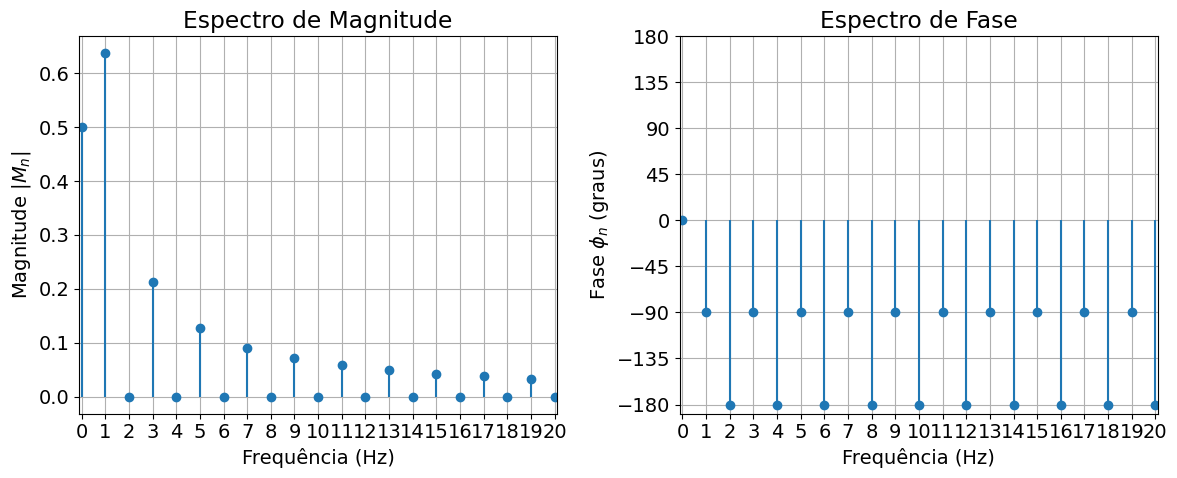

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parâmetros do Sinal 1 (Trem de Pulsos) ---
A = 1.0       # Amplitude
T0 = 1.0      # Período (segundos)
tau = 0.5     # Duração do pulso (segundos)

# Frequência angular fundamental
omega0 = 2 * np.pi / T0
# Frequência fundamental em Hz
f0 = 1 / T0

# Número de harmônicas para calcular (ex: até a 20a harmônica)
num_harmonics = 20

# Listas para armazenar os coeficientes, magnitudes e fases
n_values = []
an_values = []
bn_values = []
Mn_values = []
phi_n_values = []
freq_values = []

# --- Cálculo para n = 0 (componente DC) ---
n_values.append(0)
an_dc = (A * tau) / T0
an_values.append(an_dc)
bn_values.append(0) # b0 é sempre 0
Mn_values.append(np.abs(an_dc))
phi_n_values.append(0) # Fase para componente DC é 0
freq_values.append(0)

# --- Cálculo para n >= 1 (harmônicas) ---
for n in range(1, num_harmonics + 1):
    n_values.append(n)
    
    # Coeficiente an
    an = (A / (np.pi * n)) * np.sin(n * omega0 * tau)
    an_values.append(an)
    
    # Coeficiente bn
    bn = (A / (np.pi * n)) * (1 - np.cos(n * omega0 * tau))
    bn_values.append(bn)
    
    # Magnitude Mn
    Mn = np.sqrt(an**2 + bn**2)
    Mn_values.append(Mn)
    
    # Fase phi_n (usando atan2(y, x) -> atan2(bn, an) para nossa formulação)
    # A convenção da fase é importante. Se sua fórmula for arctan(-bn/an), então é atan2(-bn, an)
    # Vamos usar a padrão para a série trigonométrica que é atan2(bn, an)
    # Mas como o professor usa atan2(-bn, an) (pag 15), vamos com ela!
    phi_n = np.arctan2(-bn, an) 
    phi_n_values.append(phi_n)
    
    # Frequência em Hz
    freq_values.append(n * f0)

# --- Exibindo os resultados (opcional, mas bom para checar) ---
print(f"Sinal: Trem de Pulsos (A={A}, T0={T0}, tau={tau})")
print("n | an      | bn      | Magnitude | Fase (rad) | Fase (deg) | Freq (Hz)")
print("-" * 70)
for i in range(len(n_values)):
    print(f"{n_values[i]:<2} | {an_values[i]:<7.4f} | {bn_values[i]:<7.4f} | {Mn_values[i]:<9.4f} | {phi_n_values[i]:<10.4f} | {np.degrees(phi_n_values[i]):<9.2f} | {freq_values[i]:<9.2f}")

# --- Geração de Gráficos ---

# Gráfico do Espectro de Magnitude
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1o gráfico
plt.stem(freq_values, Mn_values, basefmt=" ") # Usar stem para espectro discreto
plt.title('Espectro de Magnitude')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude $|M_n|$')
plt.grid(True)
plt.xlim(-0.1, num_harmonics * f0 + 0.1) # Ajusta limites para visualização
plt.xticks(np.arange(0, num_harmonics * f0 + 1, f0)) # Marcas no eixo X em múltiplos de f0

# Gráfico do Espectro de Fase
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2o gráfico
plt.stem(freq_values, np.degrees(phi_n_values), basefmt=" ") # Fase em graus
plt.title('Espectro de Fase')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase $\phi_n$ (graus)')
plt.grid(True)
plt.xlim(-0.1, num_harmonics * f0 + 0.1)
plt.xticks(np.arange(0, num_harmonics * f0 + 1, f0))
plt.yticks(np.arange(-180, 181, 45)) # Marcas a cada 45 graus

plt.tight_layout() # Ajusta o layout para não sobrepor
plt.show()

## Programação Simbolica

In [66]:
import sympy as smp

t, f = smp.symbols('t, f', real=True)
k = smp.symbols('k', real=True, positive=True)
x = smp.exp(-k * t**2) * k * t
x

k*t*exp(-k*t**2)

In [67]:
from sympy.integrals.transforms import fourier_transform

x_FT = fourier_transform(x, t, f)
x_FT


-I*pi**(3/2)*f*exp(-pi**2*f**2/k)/sqrt(k)

<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Pedro Victor R V\AppData\Local\Temp\ipykernel_5952\4228106977.py:18: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{x}(f)|$', fontsize=20)


Text(0.5, 0, '$f$')

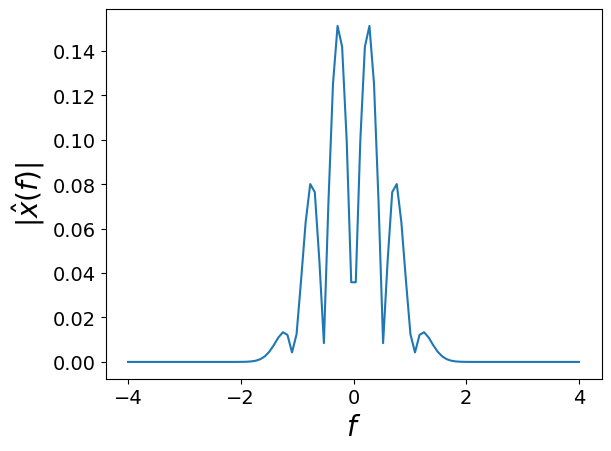

In [68]:
from scipy.integrate import quad

def x(t, k):
    return np.exp(-k * t**2) * np.sin(k*t) * t**4

def get_x_FT(x, f, k):
    x_FT_integrand_real = lambda t: np.real(x(t, k)*np.exp(-2*np.pi*1j*f*t))
    x_FT_integrand_comp = lambda t: np.imag(x(t, k)*np.exp(-2*np.pi*1j*f*t))
    x_FT_real = quad(x_FT_integrand_real, -np.inf, np.inf)[0]
    x_FT_comp = quad(x_FT_integrand_comp, -np.inf, np.inf)[0]
    return x_FT_real + 1j*x_FT_comp

f = np.linspace(-4, 4, 100)
x_FT = np.vectorize(get_x_FT)(x, f, k=2)


plt.plot(f, np.abs(x_FT))
plt.ylabel('$|\hat{x}(f)|$', fontsize=20)
plt.xlabel('$f$', fontsize=20)